Select 4 corner points on the planar surface in order:
1. Top-left
2. Top-right
3. Bottom-right
4. Bottom-left
Press any key when done...

Computed Homography Matrix:
[[ 9.92106198e-01 -1.24731311e-02  1.86000000e+02]
 [ 2.49960972e-01  7.27734022e-01  1.78000000e+02]
 [ 3.30137030e-04 -1.96936387e-05  1.00000000e+00]]


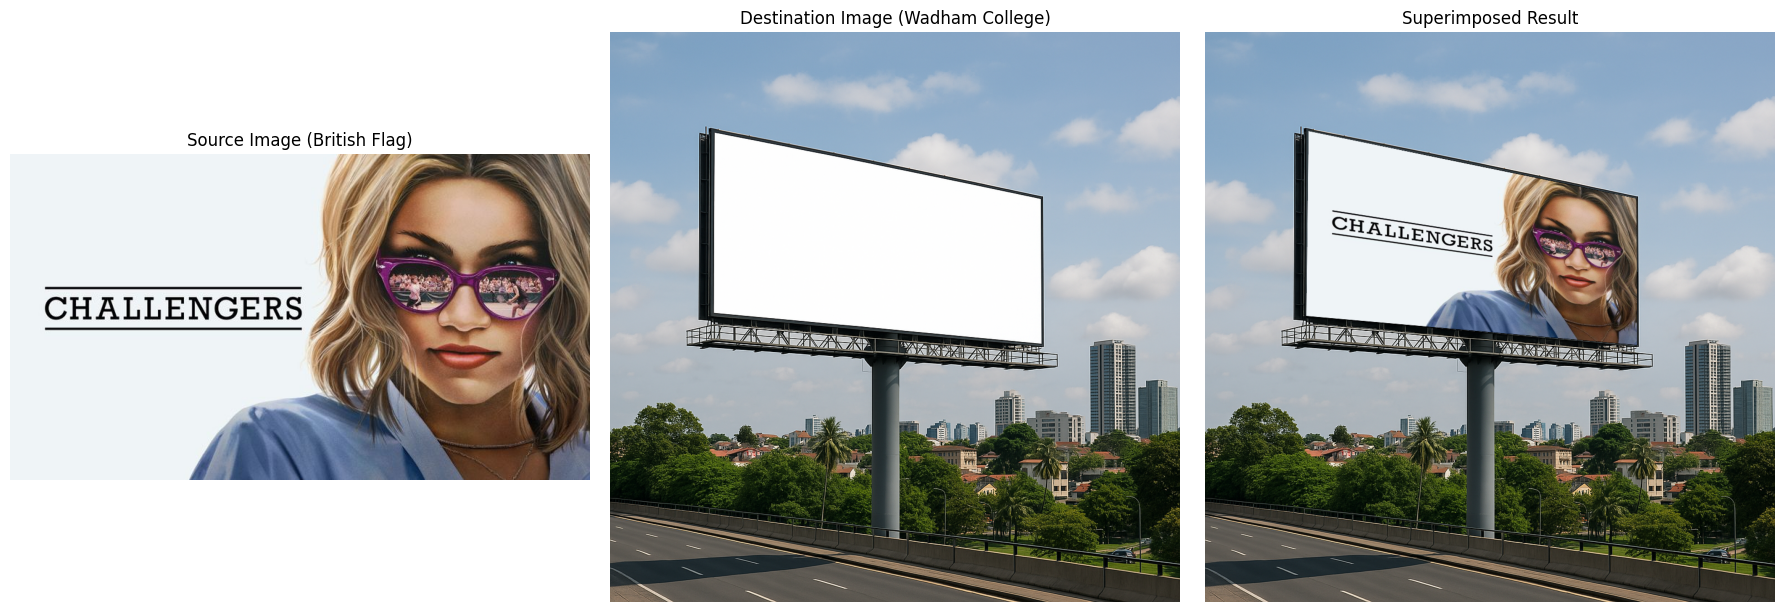

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Global variables for point selection
points = []
img_display = None

def select_points(event, x, y, flags, param):
    """Mouse callback function to select 4 corner points"""
    global points, img_display
    
    if event == cv2.EVENT_LBUTTONDOWN:
        if len(points) < 4:
            points.append([x, y])
            # Draw circle at selected point
            cv2.circle(img_display, (x, y), 5, (0, 255, 0), -1)
            cv2.putText(img_display, str(len(points)), (x+10, y+10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            cv2.imshow('Select Points', img_display)
            
            if len(points) == 4:
                # Draw quadrilateral
                for i in range(4):
                    pt1 = tuple(points[i])
                    pt2 = tuple(points[(i+1) % 4])
                    cv2.line(img_display, pt1, pt2, (0, 255, 0), 2)
                cv2.imshow('Select Points', img_display)

def superimpose_image(src_img_path, dst_img_path, output_path):
    """
    Superimpose source image onto destination image using homography
    
    Parameters:
    - src_img_path: Path to source image (e.g., British flag)
    - dst_img_path: Path to destination image (e.g., Wadham College)
    - output_path: Path to save output image
    """
    global points, img_display
    
    # Load images
    src_img = cv2.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\poster.jpg')
    dst_img = cv2.imread(r'D:\5th sem\Image proccessing\EN3160-Assignment-1---Intensity-Transformations-and-Neighborhood-Filtering\Assignment 02\billboard.png')
    
    # Initialize point selection
    points = []
    img_display = dst_img.copy()
    
    # Create window and set mouse callback
    cv2.namedWindow('Select Points')
    cv2.setMouseCallback('Select Points', select_points)
    cv2.imshow('Select Points', img_display)
    
    print("Select 4 corner points on the planar surface in order:")
    print("1. Top-left")
    print("2. Top-right")
    print("3. Bottom-right")
    print("4. Bottom-left")
    print("Press any key when done...")
    
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    
    if len(points) != 4:
        print("Error: Need exactly 4 points")
        return None
    
    # Source image corners (entire image)
    h_src, w_src = src_img.shape[:2]
    src_points = np.float32([
        [0, 0],           # Top-left
        [w_src, 0],       # Top-right
        [w_src, h_src],   # Bottom-right
        [0, h_src]        # Bottom-left
    ])
    
    # Destination points (selected by user)
    dst_points = np.float32(points)
    
    # Compute homography matrix
    H = cv2.getPerspectiveTransform(src_points, dst_points)
    
    print("\nComputed Homography Matrix:")
    print(H)
    
    # Warp source image
    warped_src = cv2.warpPerspective(src_img, H, 
                                      (dst_img.shape[1], dst_img.shape[0]))
    
    # Create mask for blending
    mask = np.zeros((dst_img.shape[0], dst_img.shape[1]), dtype=np.uint8)
    cv2.fillConvexPoly(mask, dst_points.astype(np.int32), 255)
    
    # Blend images
    result = dst_img.copy()
    mask_3channel = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    result = np.where(mask_3channel == 255, warped_src, result)
    
    # Save and display results
    cv2.imwrite(output_path, result)
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Source Image (British Flag)')
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(dst_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Destination Image (Wadham College)')
    axes[1].axis('off')
    
    axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[2].set_title('Superimposed Result')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(output_path.replace('.jpg', '_comparison.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return result, H

# Example usage
result1, H1 = superimpose_image(
    'british_flag.jpg',
    'wadham_college.jpg',
    'wadham_with_flag.jpg'
)
